<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prac 02
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [408]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

In [409]:
!wget -O h2WhitePatch.png https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/photo_21.png
!wget  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/photo_23.jpg
!wget  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/photo_22.png


--2026-05-08 08:42:14--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/h2WhitePatch.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1468779 (1.4M) [image/png]
Saving to: ‘h2WhitePatch.png’

h2WhitePatch.png    100%[===================>]   1.40M  --.-KB/s    in 0.009s  

2026-05-08 08:42:14 (151 MB/s) - ‘h2WhitePatch.png’ saved [1468779/1468779]

--2026-05-08 08:42:14--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/h2.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 441415 (431K) [image/png]
Sa

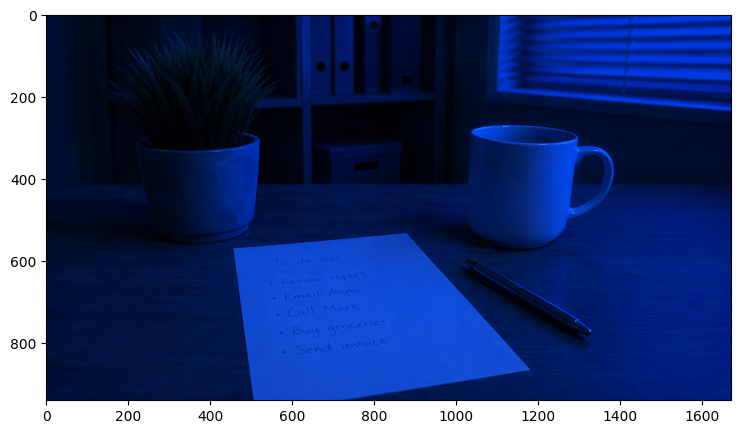

In [410]:
img = cv2.imread('h2WhitePatch.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

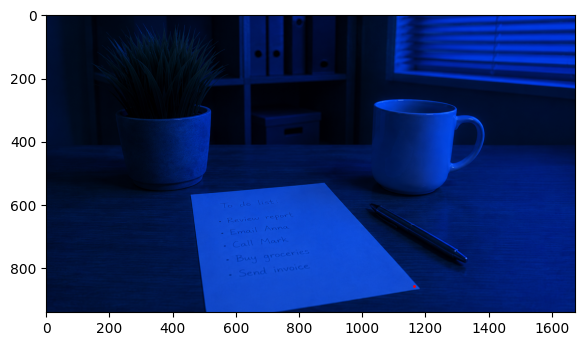

(<Axes: >, <matplotlib.image.AxesImage at 0x787d7264f920>)

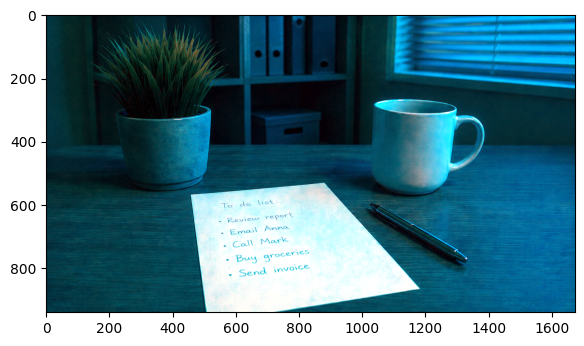

In [411]:
# Define white patch and the coefficients

row, col = 855, 1165


white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.scatter(col, row, c='red', s=1)
plt.show()
plt.subplot(122), plt.imshow(balanced)


### Gray world
This algorithm assumes that a scene, on average, is gray.

8.225074871993044 37.95499735596357 39.3231069716122


(<Axes: >, <matplotlib.image.AxesImage at 0x787d725ed2e0>)

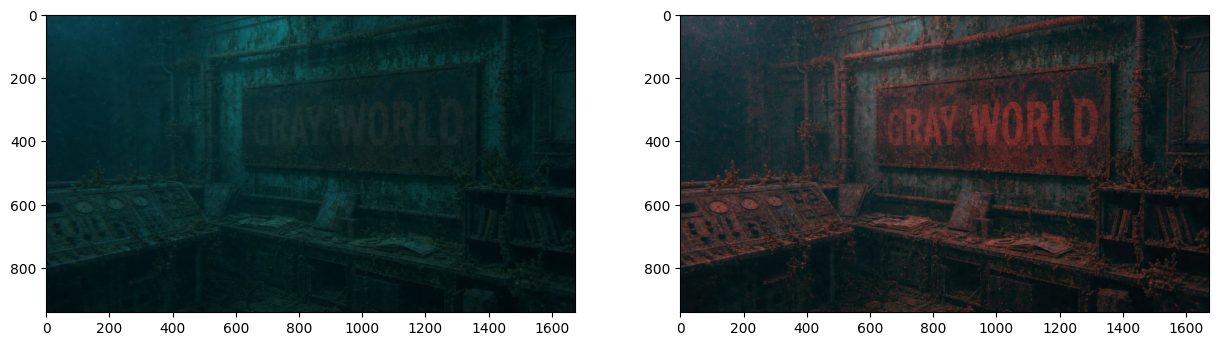

In [413]:
img = cv2.imread('photo_22.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img[:,:, 0])
mean_g = np.mean(img[:,:,1])
mean_b = np.mean(img[:,:,2])

print(mean_r, mean_g, mean_b)

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr = mean_b/mean_r
kg = mean_b/mean_g
kb = 1

# Apply color balancing and generate the balanced image
balanced = np.clip(img * [kr, kg, kb], 0, 255).astype(np.uint8)

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

75 142 124


(<Axes: >, <matplotlib.image.AxesImage at 0x787d6fc51430>)

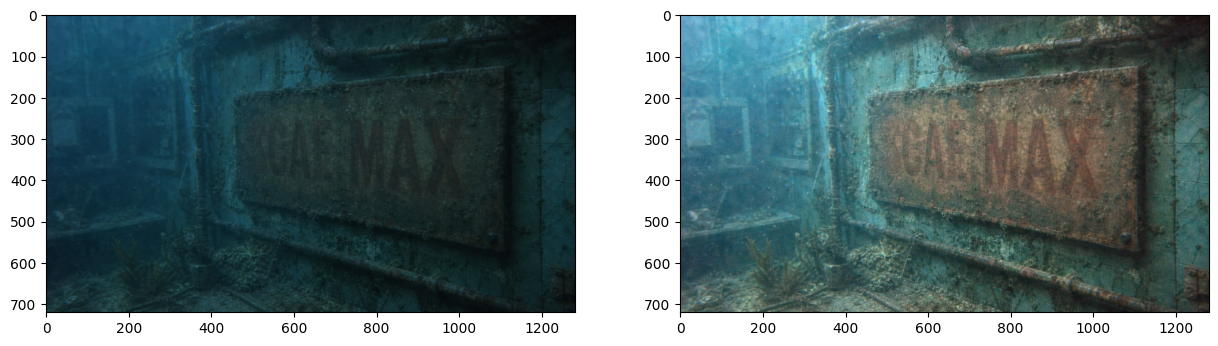

In [414]:
img = cv2.imread('photo_23.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Compute the maximum values for all three colour channels (red, green, blue)
max_r = np.max(img[:,:,0])
max_g = np.max(img[:,:,1])
max_b = np.max(img[:,:,2])
print(max_r, max_b, max_g)
# Apply scale-by-max balancing and generate the balanced image
balanced = np.clip(img * [255.0/max_r, 255.0/max_g, 255.0/max_b], 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)